# Reference Resolution Dev Notebook

In [1]:
import random
import torch
import io
import pyarrow as pa
import os
import copy
import pytorch_lightning as pl
from sacred import Experiment
from PIL import Image
from tqdm.auto import tqdm
import numpy as np
import skimage.io as skio
import matplotlib.pyplot as plt
from refer import REFER

from torch.optim import AdamW

from transformers import ElectraTokenizer

from refcoco_utils import get_bounded_subimage
from refcoco_utils import _config
from refcoco_utils import _loss_names

from meter.transforms import keys_to_transforms
from meter.config import ex
from meter.modules import METERTransformerSS
from meter.datamodules.multitask_datamodule import MTDataModule
from meter.datasets.base_dataset import BaseDataset

/home/claytonfields/anaconda3/envs/meter/lib/python3.7/site-packages/skimage/io/manage_plugins.py:23: UserWarning: Your installed pillow version is < 8.1.2. Several security issues (CVE-2021-27921, CVE-2021-25290, CVE-2021-25291, CVE-2021-25293, and more) have been fixed in pillow 8.1.2 or higher. We recommend to upgrade this library.
  from .collection import imread_collection_wrapper


## RefCOCO Data

### Utility Functions

In [2]:
def get_sent_ids(refer):
    sent_ids = []
    for ref_id in refer.getRefIds():
        ref = refer.Refs[ref_id]
        for sent_id in ref['sent_ids']:
            sent_ids.append(sent_id)
    return sent_ids

### Import  Data

In [3]:
data_root = '/home/claytonfields/nlp/code/data/coco'  # contains refclef, refcoco, refcoco+, refcocog and images
dataset = 'refcoco' 
splitBy = 'unc'
refer = REFER(data_root, dataset, splitBy)

loading dataset refcoco into memory...
testing
creating index...
index created.
DONE (t=9.71s)


In [4]:
refer.IMAGE_DIR = '/home/claytonfields/nlp/code/data/coco/images/mscoco/train2014'

## To Do: METER module may need to be updated:

1. The ref_classifier may need to be expanded to max_num_bb = 75 values

## METER Model

In [5]:
_config = copy.deepcopy(_config)
pl.seed_everything(_config["seed"])

dm = MTDataModule(_config, dist=False)
model = METERTransformerSS(_config)
exp_name = f'{_config["exp_name"]}'
os.makedirs(_config["log_dir"], exist_ok=True)
checkpoint_callback = pl.callbacks.ModelCheckpoint(
    save_top_k=1,
    verbose=True,
    monitor="val/the_metric",
    mode="max",
    save_last=True,
)
logger = pl.loggers.TensorBoardLogger(
    _config["log_dir"],
    name=f'{exp_name}_seed{_config["seed"]}_from_{_config["load_path"].split("/")[-1][:-5]}',
)

lr_callback = pl.callbacks.LearningRateMonitor(logging_interval="step")
callbacks = [checkpoint_callback, lr_callback]

num_gpus = (
    _config["num_gpus"]
    if isinstance(_config["num_gpus"], int)
    else len(_config["num_gpus"])
)

grad_steps = max(_config["batch_size"] // (
    _config["per_gpu_batchsize"] * num_gpus * _config["num_nodes"]
), 1)

max_steps = _config["max_steps"] if _config["max_steps"] is not None else None

trainer = pl.Trainer(
    gpus=_config["num_gpus"],
    num_nodes=_config["num_nodes"],
    precision=_config["precision"],
    benchmark=True,
    deterministic=True,
    max_epochs=_config["max_epoch"] if max_steps is None else 1000,
    max_steps=max_steps,
    callbacks=callbacks,
    logger=logger,
    #prepare_data_per_node=False,
    #replace_sampler_ddp=False,
    accumulate_grad_batches=grad_steps,
    log_every_n_steps=10,
    flush_logs_every_n_steps=10,
    resume_from_checkpoint=_config["resume_from"],
    weights_summary="top",
    fast_dev_run=_config["fast_dev_run"],
    val_check_interval=_config["val_check_interval"],
)

# if not _config["test_only"]:
#     trainer.fit(model, datamodule=dm)
# else:
#     trainer.test(model, datamodule=dm)

Global seed set to 0
Some weights of the model checkpoint at google/electra-small-discriminator were not used when initializing ElectraModel: ['discriminator_predictions.dense.weight', 'discriminator_predictions.dense.bias', 'discriminator_predictions.dense_prediction.bias', 'discriminator_predictions.dense_prediction.weight']
- This IS expected if you are initializing ElectraModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing ElectraModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
GPU available: True, used: True
TPU available: False, using: 0 TPU cores


In [6]:
sent_ids = get_sent_ids(refer)
sent_id = sent_ids[0]
ref = refer.sentToRef[0]
refer.Sents[0]

{'tokens': ['the', 'lady', 'with', 'the', 'blue', 'shirt'],
 'raw': 'THE LADY WITH THE BLUE SHIRT',
 'sent_id': 0,
 'sent': 'the lady with the blue shirt'}

## To Do: Write New Data Class for Ref Res with multiple samples

1. Deliver single sentence with sub-images and text_labels, masks and ids so that METER can perform all subimage at once.

2.  May require padding to max_num_bb = 75

In [7]:
class RefcocoDataset(torch.utils.data.Dataset):

    def __init__(self, refer, tokenizer, max_bb = 75):
        self.tokenizer = tokenizer
        self.refer = refer
        self.max_bb = max_bb
        self.sent_ids = self.get_sent_ids()
#         self.targets = labels
#         self.max_len = max_len

    def __len__(self):
        return len(self.sent_ids)
    
    def get_sent_ids(self):
        sent_ids = []
        for ref_id in self.refer.getRefIds():
            ref = self.refer.Refs[ref_id]
            for sent_id in ref['sent_ids']:
                sent_ids.append(sent_id)
        return sent_ids

    def __getitem__(self, index):
        sent = self.refer.Sents[index]
        ref = self.refer.sentToRef[index]
        img_id = ref['image_id']
        ann_id = ref['ann_id']
        objs = refer.imgToAnns[img_id]
        obj_ids = [obj['id'] for obj in objs]
        
        sub_images = []
        for obj in objs:
            x_a = get_bounded_subimage(refer, img_id, obj['id'], xs=224,ys=224, show=False)
            if x_a is not None:
                sub_images.append(x_a)
        num_sub_images = len(sub_images)      
            
        text_ids = tokenizer.encode(
            sent['sent'],
            padding="max_length",
            truncation=True,
            max_length=40,
            return_special_tokens_mask=True,
        )
        text_masks = [1 if text_ids[i]>0 else 0 for i,_ in enumerate(text_ids)]
        text_labels = [[-100 for i in range(40)]]

        ids = [text_ids for i in range(num_sub_images)]
        masks = [text_masks for _ in range(num_sub_images)]
        labels = [text_labels for i in range(num_sub_images)]
            
        ### TODO: Put all of the sub images in the infer dict with the coressponding sentence.
        return_dict = {
            'ann_id' : ann_id,
            'image' : sub_images,
            'obj_ids' : obj_ids,
            'text' : sent['sent'],
            'text_ids' : torch.tensor(ids),
            'text_labels' : torch.tensor(labels),
            'text_masks' : torch.tensor(masks)
        }  

        return return_dict

In [270]:
class NewRefcocoDataset(torch.utils.data.Dataset):

    def __init__(self, refer, tokenizer, max_bb = 75, max_tokens = 40):
        self.tokenizer = tokenizer
        self.refer = refer
        self.max_bb = max_bb
        self.max_tokens = max_tokens
        self.sent_ids = self.get_sent_ids()

    def __len__(self):
        return len(self.sent_ids)
    
    def get_sent_ids(self):
        sent_ids = []
        for ref_id in self.refer.getRefIds():
            ref = self.refer.Refs[ref_id]
            for sent_id in ref['sent_ids']:
                sent_ids.append(sent_id)
        return sent_ids
    
    def __getitem__(self, index):
        max_bb = self.max_bb
        sent = refer.Sents[index]
        ref = refer.sentToRef[index]
        img_id = ref['image_id']
        ann_id = ref['ann_id']
        objs = refer.imgToAnns[img_id]
        obj_ids = [obj['id'] for obj in objs]
        obj_pad = [0 for _ in range(max_bb-len(obj_ids))]
        obj_ids_total = obj_ids+obj_pad

        sub_images = []
        for obj in objs:
            x_a = get_bounded_subimage(refer, img_id, obj['id'], xs=224,ys=224, show=False)
            if x_a is not None:
                sub_images.append(x_a)
        
        num_sub_images = len(sub_images)
        num_pad = max_bb - num_sub_images 
        
        pad_image = torch.zeros(1,3,224,224)
        for _ in range(max_bb - num_sub_images):
            sub_images.append(pad_image)
        
        # text ids
        ids = tokenizer.encode(
            sent['sent'],
            padding="max_length",
            truncation=True,
            max_length=40,
            return_special_tokens_mask=True,
        )
        repeat_ids = torch.tensor(ids).repeat(num_sub_images,1)
        pad_ids =  torch.zeros(num_pad,40)
        text_ids = torch.concat((repeat_ids, pad_ids)).to(torch.int)
        # text masks
        num_tokens = torch.where(text_ids[0] > 0)[0].size(dim=0)
        masks = torch.concat((torch.ones(num_tokens), torch.zeros(40-num_tokens))).to(torch.int)
        repeat_masks = masks.repeat(num_sub_images,1)
        pad_masks = torch.zeros(num_pad, 40)
        text_masks = torch.concat((repeat_masks, pad_masks)).to(torch.int)
        # text_labels
        labels = torch.full((40,),-100)
        repeat_labels = labels.repeat(num_sub_images, 1)
        pad_labels = torch.zeros(num_pad, 40)
        text_labels = torch.concat((repeat_labels, pad_labels)).to(torch.int)

        return_dict = {
            'ann_id' : ann_id,
            'image' : sub_images,
            'obj_ids' : torch.tensor(obj_ids_total),
            'text' : sent['sent'],
            'text_ids' : text_ids,
            'text_labels' : text_labels,
            'text_masks' : text_masks
        }
        
        return return_dict

In [9]:
index = 0
max_bb = 75
sent = refer.Sents[index]
ref = refer.sentToRef[index]
img_id = ref['image_id']
ann_id = ref['ann_id']
objs = refer.imgToAnns[img_id]
obj_ids = [obj['id'] for obj in objs]
obj_pad = [0 for _ in range(max_bb-len(obj_ids))]
obj_ids = obj_ids+obj_pad

sub_images = []
for obj in objs:
    x_a = get_bounded_subimage(refer, img_id, obj['id'], xs=224,ys=224, show=False)
    if x_a is not None:
        sub_images.append(x_a)
num_sub_images = len(sub_images)
max_bb = 75
num_pad = max_bb - num_sub_images 
pad_image = torch.zeros(1,3,224,224)
for _ in range(max_bb - num_sub_images):
    sub_images.append(pad_image)

ids = tokenizer.encode(
    sent['sent'],
    padding="max_length",
    truncation=True,
    max_length=40,
    return_special_tokens_mask=True,
)

# text ids
repeat_ids = torch.tensor(ids).repeat(num_sub_images,1)
pad_ids =  torch.zeros(num_pad,40)
text_ids = torch.concat((repeat_ids, pad_ids)).to(torch.int)
# text masks
# text_masks = torch.tensor([1 if ids[i]>0 else 0 for i,_ in enumerate(ids)])
num_tokens = torch.where(text_ids[0] > 0)[0].size(dim=0)
masks = torch.concat((torch.ones(num_tokens), torch.zeros(40-num_tokens))).to(torch.int)
repeat_masks = masks.repeat(num_sub_images,1)
pad_masks = torch.zeros(num_pad, 40)
text_masks = torch.concat((repeat_masks, pad_masks)).to(torch.int)
# text_labels
labels = torch.full((40,),-100)
repeat_labels = labels.repeat(num_sub_images, 1)
pad_labels = torch.zeros(num_pad, 40)
text_labels = torch.concat((repeat_labels, pad_labels)).to(torch.int)


# ids = [text_ids for i in range(num_sub_images)]
# masks = [text_masks for _ in range(num_sub_images)]
# labels = [text_labels for i in range(num_sub_images)]

### TODO: Put all of the sub images in the infer dict with the coressponding sentence.
return_dict = {
    'ann_id' : ann_id,
    'image' : sub_images,
    'obj_ids' : torch.tensor(obj_ids),
    'text' : sent['sent'],
    'text_ids' : text_ids,
    'text_labels' : text_labels,
    'text_masks' : text_masks
}

# obj_ids.__len__()

NameError: name 'tokenizer' is not defined

In [262]:
obj_pad = [0 for _ in range(max_bb-len(obj_ids))]
obj_ids = obj_ids+obj_pad
obj_ids.__len__()

75

## Ref Res with METER

In [10]:
optim = AdamW(model.parameters(), lr=1e-4)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Ref Res with METER
tokenizer = ElectraTokenizer.from_pretrained('google/electra-small-discriminator')
BATCH_SIZE = 1


epochs = 1
# loader = dm.train_dataloader()
optim = AdamW(model.parameters(), lr=1e-4)
loss_fn = torch.nn.functional.cross_entropy
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [11]:
ds = RefcocoDataset(refer, tokenizer)
ds

In [12]:
train_params = {'batch_size': BATCH_SIZE,
                'shuffle': False,
                'num_workers': 0
                }

training_loader = torch.utils.data.DataLoader(ds, **train_params)

In [13]:
for i, data in enumerate(training_loader):
    if i==0:
        break
data['obj_ids'].__len__()

33

### Training Loop

The cell below contains code to score multiple image text pairs at a given time.

### To Do:

1. Get targets in dataset's get_item method

#### Model for Batch_Size > 1

#### Training Loop with Data Class

In [351]:
refer.annToRef[data['ann_id']]

{'sent_ids': [729, 730, 731],
 'file_name': 'COCO_train2014_000000579138_3.jpg',
 'ann_id': 457633,
 'ref_id': 255,
 'image_id': 579138,
 'split': 'train',
 'sentences': [{'tokens': ['man', 'on', 'left'],
   'raw': 'man on left',
   'sent_id': 729,
   'sent': 'man on left'},
  {'tokens': ['man', 'on', 'the', 'left'],
   'raw': 'man on the left',
   'sent_id': 730,
   'sent': 'man on the left'},
  {'tokens': ['left', 'man', 'sorry'],
   'raw': 'left man sorry',
   'sent_id': 731,
   'sent': 'left man sorry'}],
 'category_id': 1}

In [352]:

model.train()
losses = []
for data in tqdm(ds):
    
    optim.zero_grad()
    
    try:
        infer_dict = model.infer(data)
        logits = model.ref_classifier(infer_dict['cls_feats'])

        obj_ids = data['obj_ids']
        ann_id = data['ann_id']
    #     target = torch.where(obj_ids==ann_id)

        target = torch.tensor([obj_ids.index(ann_id)])
        loss = loss_fn(logits.reshape(1,-1),target)
        losses.append(loss.item())
        loss.backward()

    # Adjust learning weights
        optim.step()
    except RuntimeError:
        print(f'RuntimeError')
    

  0%|          | 0/142210 [00:00<?, ?it/s]

RuntimeError
RuntimeError
RuntimeError
RuntimeError
RuntimeError
RuntimeError
RuntimeError
RuntimeError
RuntimeError
RuntimeError
RuntimeError


KeyboardInterrupt: 

#### Full Training Loop

In [74]:
# Create loop for ref res
train_ids = refer.getRefIds(split='train')
text_labels = [[-100 for i in range(40)]]
# train_ids = train_ids[:5]

losses = []
model.train()
for ref_id in tqdm(train_ids):
    ref = refer.Refs[ref_id]
    img_id = ref['image_id']
    ann_id = ref['ann_id']
    objs = refer.imgToAnns[img_id]
    obj_ids = [obj['id'] for obj in objs]
    
    sub_images = []
    for obj in objs:
        x_a = get_bounded_subimage(refer, img_id, obj['id'], xs=224,ys=224, show=False)
        if x_a is not None:
            sub_images.append(x_a)
    num_sub_images = len(sub_images)
        
    
    for sent in ref['sentences']:
        
        
        text_ids = tokenizer.encode(
            sent['sent'],
            padding="max_length",
            truncation=True,
            max_length=40,
            return_special_tokens_mask=True,
        )
        text_masks = [1 if text_ids[i]>0 else 0 for i,_ in enumerate(text_ids)]
        text_labels = [[-100 for i in range(40)]]

        ids = [text_ids for i in range(num_sub_images)]
        masks = [text_masks for _ in range(num_sub_images)]
        labels = [text_labels for i in range(num_sub_images)]
        optim.zero_grad()

        ### TODO: Put all of the sub images in the infer dict with the coressponding sentence.

        input_dict = {
            'image' : sub_images,
            'text' : sent,
            'text_ids' : torch.tensor(ids),
            'text_labels' : torch.tensor(labels),
            'text_masks' : torch.tensor(masks)
        }
        
        infer_dict = model.infer(input_dict)
        logits = model.ref_classifier(infer_dict['cls_feats'])
        
        
        target = torch.tensor([obj_ids.index(ann_id)])
        loss = loss_fn(logits.reshape(1,-1),target)
        losses.append(loss.item())
        loss.backward()

        # Adjust learning weights
        optim.step()

  0%|          | 0/42404 [00:00<?, ?it/s]

KeyboardInterrupt: 

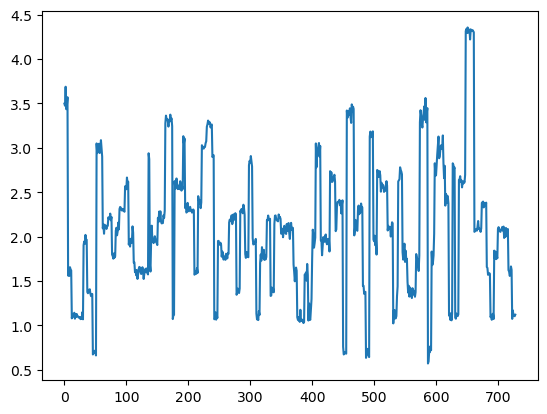

In [333]:
import matplotlib.pyplot as plt
plt.plot(losses)

In [70]:
target

tensor([0])

In [73]:
loss.item()

2.619197130203247

## Test Cells:

### Test Data Module

In [23]:
from refcoco_utils import _config
dm = MTDataModule(_config, dist=False)
dm.batch_size = 2

dm.prepare_data()
dm.setup('fit')
loader = dm.train_dataloader()

In [26]:
for i, batch in enumerate(loader):
    if i ==1:
        break
batch

### Find Max Number of Objects

In [34]:
size = []
for ref_id in train_ids:
    ref = refer.Refs[ref_id]
    img_id = ref['image_id']
    ann_id = ref['ann_id']
    objs = refer.imgToAnns[img_id]
    size.append(len(objs))
max_size = max(size)
print(f'The most objects in any reference is {max_size}')


The most objects in any reference is 75


In [46]:
size = []
for ref_id in train_ids:
    ref = refer.Refs[ref_id]
    
    size.append(len(ref['sentences']))
max_size = max(size)
print(f'The most sentences in any reference is {max_size}')

The most sentences in any reference is 6


In [43]:
ref['sentences'].__len__()

2

### Previous Training Loop

#### Single Example

In [62]:
ref_id = 0
ref = refer.Refs[ref_id]
img_id = ref['image_id']
ann_id = ref['ann_id']
objs = refer.imgToAnns[img_id]
obj_ids = [obj['id'] for obj in objs]

sub_images = []
for obj in objs:
    x_a = get_bounded_subimage(refer, img_id, obj['id'], xs=224,ys=224, show=False)
    if x_a is not None:
        sub_images.append(x_a)
num_sub_images = len(sub_images)

sent = ref['sentences'][0]
text_ids = tokenizer.encode(
            sent['sent'],
            padding="max_length",
            truncation=True,
            max_length=40,
            return_special_tokens_mask=True,
)
text_masks = [1 if text_ids[i]>0 else 0 for i,_ in enumerate(text_ids)]
text_labels = [[-100 for i in range(40)]]

ids = [text_ids for i in range(num_sub_images)]
masks = [text_masks for _ in range(num_sub_images)]
labels = [text_labels for i in range(num_sub_images)]

input_dict = {
    'image' : sub_images,
    'text' : sent,
    'text_ids' : torch.tensor(ids),
    'text_labels' : torch.tensor(labels),
    'text_masks' : torch.tensor(masks)
}
infer_dict = model.infer(input_dict)
model.ref_classifier(infer_dict['cls_feats'])

tensor([[1.8886],
        [1.9706],
        [1.9410],
        [1.9694],
        [1.9764],
        [2.0338],
        [1.8152],
        [1.9130],
        [1.8890],
        [2.0255],
        [1.9955],
        [1.9540],
        [1.9893],
        [1.9395],
        [1.8477],
        [1.9534],
        [1.9033],
        [1.9261],
        [1.9442],
        [1.8642],
        [1.9500],
        [1.8388],
        [1.8781],
        [1.9925],
        [2.0712],
        [1.9615],
        [2.0073],
        [1.9255],
        [1.8513],
        [1.9537],
        [1.8977],
        [1.8888],
        [1.8180]], grad_fn=<AddmmBackward0>)

#### Full Loop

In [15]:
# Create loop for ref res
train_ids = refer.getRefIds(split='train')
text_labels = [[-100 for i in range(40)]]
# train_ids = train_ids[:5]

losses = []
model.train()
for ref_id in tqdm(train_ids):
    ref = refer.Refs[ref_id]
    img_id = ref['image_id']
    ann_id = ref['ann_id']
    objs = refer.imgToAnns[img_id]
    obj_ids = [obj['id'] for obj in objs]
    
    sub_images = []
    for obj in objs:
        x_a = get_bounded_subimage(refer, img_id, obj['id'], xs=224,ys=224, show=False)
        if x_a is not None:
            sub_images.append(x_a)
    num_sub_images = len(sub_images)
        
    
    for sent in ref['sentences']:
        
        
        text_ids = tokenizer.encode(
            sent['sent'],
            padding="max_length",
            truncation=True,
            max_length=40,
            return_special_tokens_mask=True,
        )
        text_masks = [1 if text_ids[i]>0 else 0 for i,_ in enumerate(text_ids)]
        text_labels = [[-100 for i in range(40)]]

        ids = [text_ids for i in range(num_sub_images)]
        masks = [text_masks for _ in range(num_sub_images)]
        labels = [text_labels for i in range(num_sub_images)]
        optim.zero_grad()

        ### TODO: Put all of the sub images in the infer dict with the coressponding sentence.

        input_dict = {
            'image' : sub_images,
            'text' : sent,
            'text_ids' : torch.tensor(ids),
            'text_labels' : torch.tensor(labels),
            'text_masks' : torch.tensor(masks)
        }
        
        infer_dict = model.infer(input_dict)
        logits = model.ref_classifier(infer_dict['cls_feats'])
        
        
        target = torch.tensor([obj_ids.index(ann_id)])
        loss = loss_fn(logits.reshape(1,-1),target)
        losses.append(loss.item())
        loss.backward()

        # Adjust learning weights
        optim.step()

  0%|          | 0/42404 [00:00<?, ?it/s]

KeyboardInterrupt: 

### Previous Eval Loop

In [25]:
## Eval Loop
eval_ids = refer.getRefIds(split='val')[:1]
with torch.no_grad():
    gold = []
    for ref_id in tqdm(eval_ids):
        ref = refer.Refs[ref_id]
        img_id = ref['image_id']
        ann_id = ref['ann_id']
        objs = refer.imgToAnns[img_id]
        obj_ids = [obj['id'] for obj in objs]
    
        sub_images = []
        for obj in objs:
            x_a = get_bounded_subimage(refer, img_id, obj['id'], xs=224,ys=224, show=False)
            if x_a is not None:
                sub_images.append(x_a)
        num_sub_images = len(sub_images)
        for sent in ref['sentences']:
            scores = []
            text_ids = tokenizer.encode(
                sent['sent'],
                padding="max_length",
                truncation=True,
                max_length=40,
                return_special_tokens_mask=True,
            )
            text_masks = torch.tensor([1 if text_ids[i]>0 else 0 for i,_ in enumerate(text_ids)]).reshape(1,-1)
    
            for sub_image in sub_images:
                # assert not torch.isnan(x_a).any()
                input_dict = {
                    'image' : [sub_image],
                    'text' : sent,
                    'text_ids' : torch.tensor(text_ids).reshape(1,-1),
                    'text_labels' : text_labels,
                    'text_masks' : text_masks
                }
                infer_dict = model.infer(input_dict)
                score = model.ref_classifier(infer_dict['cls_feats'])
                scores.append(score)

            pred_index = np.argmax(scores)
            pred_id = objs[pred_index]['id']
            target = torch.tensor([obj_ids.index(ann_id)])
            scores = torch.cat(scores)
            if pred_id == ann_id:
                gold.append(1)
            else:
                gold.append(0)

  0%|          | 0/1 [00:00<?, ?it/s]

In [30]:
scores.shape

torch.Size([20, 1])

In [27]:
pred_index

1

In [28]:
pred_id

706902

In [29]:
ann_id

1537681

In [32]:
len(objs)

20